# Import dos dados e bibliotecas

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import pyarrow

In [2]:
df_caminhao = pd.read_parquet('datasets/datasets_tratados/df_caminhao_pre_processamento.parquet', engine="pyarrow")
# df_escavadeira = pd.read_parquet('datasets/datasets_tratados/df_escavadeira_pre_processamento.parquet', engine="pyarrow")

# Avaliando a distribuição dos erros

## Para Caminhões

In [3]:
pd.crosstab(df_caminhao['TAG'], df_caminhao['Situacao_Operacional'])

Situacao_Operacional,Hibernando,Manutenção,Operando,Parado
TAG,,,,
CA5926,0,7990,88748,10488
CA5927,0,3286,47354,3646
CA65789,1043,1320,44070,2439
CA65790,0,6866,134122,14041
CA65791,871,0,0,0
CA65792,0,12024,103714,10813
CA65793,2637,3456,40057,3507
CA65902,53,1315,22163,1851
CA65908,801,2347,26789,2486


In [4]:
pd.crosstab(df_caminhao['TAG'], df_caminhao['Is_Dont_Go'])

Is_Dont_Go,0,1
TAG,,
CA5926,106754,472
CA5927,53815,471
CA65789,48833,39
CA65790,154964,65
CA65791,871,0
CA65792,124962,1589
CA65793,49651,6
CA65902,24964,418
CA65908,31720,703


In [5]:
pd.crosstab(df_caminhao['TAG'], df_caminhao['Criticidade'])

Criticidade,Crítico,Informacional,Não Crítico
TAG,,,
CA5926,1482,100932,4812
CA5927,2215,46609,5462
CA65789,655,46467,1750
CA65790,2491,148177,4361
CA65791,0,860,11
CA65792,488,108334,17729
CA65793,185,48874,598
CA65902,214,21121,4047
CA65908,4096,24737,3590


A principio serão removidos os erros gerados por caminhões que só hibernaram durante todo o período dos dados estamos assumindo que esses erros não foram gerados durante a operação do equipamento e portanto não contribuirão para a modelagem

Lista de tags a serem dropadas:
- CA65791
- CA65917

In [6]:
list_index = df_caminhao[df_caminhao['TAG'].isin(['CA65791', 'CA65917'])].index
df_caminhao.drop(list_index, inplace=True)

## Para Escavadeiras

In [7]:
pd.crosstab(df_escavadeira['TAG'], df_escavadeira['Situacao_Operacional'])

NameError: name 'df_escavadeira' is not defined

In [ ]:
pd.crosstab(df_escavadeira['TAG'], df_escavadeira['Is_Dont_Go'])

In [ ]:
pd.crosstab(df_escavadeira['TAG'], df_escavadeira['Criticidade'])

# Avaliando Séries dos Erros

In [8]:
df_caminhao

,Data_Evento,Dia,TAG,Tag_Frota,Tipo,Nome_Operador_Anon,Alarme,Criticidade,Valor,Classe,Is_Dont_Go,Situacao_Operacional,Turno,Tempo_Situacao,Tempo_Turno,Mes
0,2025-01-01 00:00:05.790,1,CA65792,793-D 2S,Caminhao,OP_322,dipper,Informacional,97.400002,NULL,0,Operando,Turno 18-6,5,21605,1
1,2025-01-01 00:00:12.537,1,CA65922,793-D 4S,Caminhao,OP_109,dipper,Informacional,203.600006,NULL,0,Operando,Turno 18-6,12,21612,1
2,2025-01-01 00:00:14.553,1,CA5926,793-D 5S,Caminhao,OP_261,rx channel a not receiving messages,Informacional,0.000000,NULL,0,Operando,Turno 18-6,14,21614,1
3,2025-01-01 00:00:14.553,1,CA5926,793-D 5S,Caminhao,OP_261,rx channel b not receiving messages,Informacional,0.000000,NULL,0,Operando,Turno 18-6,14,21614,1
4,2025-01-01 00:00:31.807,1,CA65933,793-D 5S,Caminhao,OP_141,body up,Informacional,4.000000,NULL,0,Operando,Turno 18-6,31,21631,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3281758,2025-06-30 23:59:40.767,30,CA65793,793-D 2S,Caminhao,OP_261,rx channel a not receiving messages,Informacional,0.000000,NULL,0,Operando,Turno 18-6,3069,21580,6
3281759,2025-06-30 23:59:41.847,30,CA65935,793-D 5S,Caminhao,OP_196,5th tire tag timeout,Informacional,0.000000,NULL,0,Operando,Turno 18-6,364,21581,6
3281760,2025-06-30 23:59:53.647,30,CA65935,793-D 5S,Caminhao,OP_196,rx channel a not receiving messages,Informacional,0.000000,NULL,0,Operando,Turno 18-6,376,21593,6
3281761,2025-06-30 23:59:53.647,30,CA65935,793-D 5S,Caminhao,OP_196,rx channel b not receiving messages,Informacional,0.000000,NULL,0,Operando,Turno 18-6,376,21593,6


In [9]:
df_caminhao['Situacao_Operacional'].unique()

<ArrowStringArray>
['Operando', 'Manutenção', 'Parado', 'Hibernando']
Length: 4, dtype: str

In [10]:
def plot_serie_temporal_tag(tag_selecionada):

    df_tag = df_caminhao[df_caminhao['TAG'] == tag_selecionada].copy()

    # Garantimos que está ordenado por data
    df_tag = df_tag.sort_values(by='Data_Evento')

    # Contagem cumulativa contínua global
    df_tag['contagem_cumulativa'] = range(1, len(df_tag) + 1)

    # ==========================================
    # MAPEAMENTO DE CORES PARA OS STATUS
    # ==========================================
    # Ajuste os nomes das chaves de acordo com as strings exatas da sua coluna
    cores_status = {
        'Operando': '#2ecc71',  # Verde
        'Manutenção': '#3498db',  # Azul
        'Parado': '#95a5a6',
        'Hibernando': '#d3d3d3',  # Cinza
    }

    # ==========================================
    # 3. PLOTANDO O GRÁFICO SEPARADO POR MÊS
    # ==========================================
    sns.set_theme(style="whitegrid")

    # Criamos a grade separando pela coluna 'Mes'
    g = sns.FacetGrid(
        df_tag,
        col="Mes",
        col_wrap=3,
        sharex=False,
        sharey=False,  # Mantém o foco na faixa acumulada de cada mês
        height=4,
        aspect=1.3,
    )

    # Passo A: Linha mestre em degraus (esqueleto neutro do acúmulo)
    g.map_dataframe(
        sns.lineplot,
        x="Data_Evento",
        y="contagem_cumulativa",
        drawstyle='steps-pre',
        color='#bdc3c7',
        alpha=0.6,
        linewidth=1.5,
    )

    # Passo B: Função customizada para plotar as situações e os Don't Go
    def plot_detalhes_operacionais(data, **kwargs):
        if data.empty:
            return

        # 1. Plota todos os erros como pontinhos coloridos pelo status operacional atual
        # Usamos um tamanho controlado (s=25) para não sobrepor totalmente a linha
        # IMPORTANTE: Altere 'Situacao_Operacional' para o nome real da sua coluna de status
        sns.scatterplot(
            data=data,
            x="Data_Evento",
            y="contagem_cumulativa",
            hue="Situacao_Operacional",
            palette=cores_status,
            s=15,
            alpha=0.8,
            edgecolor=None,
            zorder=4,
        )

        # 2. Aplica o 'X' Vermelho Soberano exatamente onde houve o Don't Go
        df_critico = data[data['Is_Dont_Go'] == 1]
        if not df_critico.empty:
            plt.scatter(
                df_critico['Data_Evento'],
                df_critico['contagem_cumulativa'],
                color='red',
                marker='X',  # O 'X' destaca muito mais que uma bolinha
                s=50,  # Bem maior para sobressair no meio dos outros pontos
                zorder=5,
            )

    # Aplicando a nossa função lógica na grade
    g.map_dataframe(plot_detalhes_operacionais)

    # Ajustes de estética dos eixos
    g.set_axis_labels("Data do Evento", "Total de Alarmes Acumulados")
    g.set_titles(col_template="Mês: {col_name}")

    # Rotacionando as datas no eixo X para ficar legível
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)

    # ==========================================
    # CRIAÇÃO DA LEGENDA MANUAL GLOBAL
    # ==========================================
    # Construímos a legenda do zero para evitar duplicações e bugs de mapeamento do FacetGrid
    legend_elements = [
        mlines.Line2D(
            [0],
            [0],
            color='#bdc3c7',
            linewidth=2,
            label='Tendência Global de Alarmes',
        ),
        mlines.Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            markerfacecolor='#2ecc71',
            markersize=8,
            label='Status: Operação',
        ),
        mlines.Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            markerfacecolor='#3498db',
            markersize=8,
            label='Status: Manutenção',
        ),
        mlines.Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            markerfacecolor='#95a5a6',
            markersize=8,
            label='Status: Hibernando',
        ),
        mlines.Line2D(
            [0],
            [0],
            marker='X',
            color='w',
            markerfacecolor='red',
            markeredgecolor='red',
            markersize=9,
            label="Evento 'Don't Go'",
        ),
    ]

    # Joga a legenda para fora dos gráficos, centralizada à direita
    g.fig.legend(
        handles=legend_elements,
        loc='center left',
        bbox_to_anchor=(1.01, 0.5),
        title="Dicionário de Eventos",
    )

    plt.suptitle(
        f"Análise de Alarmes por Estado Operacional - Equipamento: {tag_selecionada}",
        y=1.05,
        fontsize=16,
    )

    # Ajusta o layout deixando uma margem na direita (rect) para a legenda não ser cortada
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()

KeyboardInterrupt: 

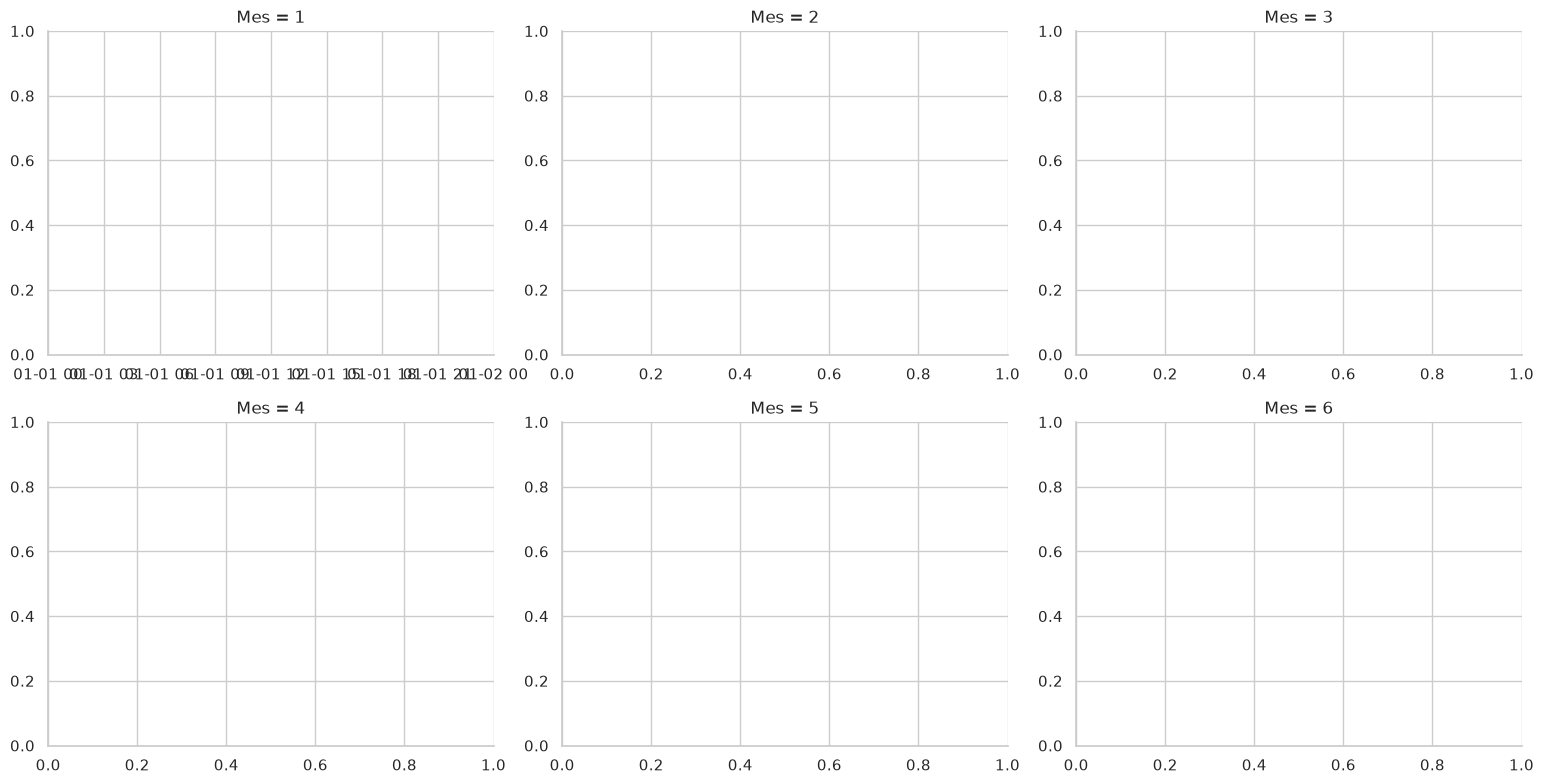

In [11]:
tags = df_caminhao['TAG'].unique()

for tag in tags:
    plot_serie_temporal_tag(tag)

In [12]:
crosstab_alarme_criticidade = pd.crosstab(
    df_caminhao['Alarme'],
    df_caminhao['Criticidade']
)

crosstab_alarme_criticidade

Criticidade,Crítico,Informacional,Não Crítico
Alarme,,,
1st tire pressure high maximum,0,9,0
1st tire pressure low,0,1172,0
1st tire pressure low minimum,273,1374,4
1st tire pressure very low,267,0,0
1st tire tag high pressure change rate,0,1107,0
...,...,...,...
vims snapshot - inactive,0,3,0
vims transmission ecm - active,0,0,226
vims transmission ecm - inactive,0,203,0


# Salvando os dados limpos

In [13]:
df_caminhao.to_parquet('datasets/datasets_tratados/df_caminhao_limpo.parquet', engine='pyarrow')
# df_escavadeira.to_parquet('datasets/datasets_tratados/df_escavadeira_limpo.parquet', engine='pyarrow')